# EECE 4632 Project Notebook  
## Frequency Hopping Spread Spectrum (FHSS) Software Prototype

**Camille Ferrell & Liam McCarthy**  
**Professor Leeser**  
**Software milestone notebook**

This notebook builds a complete software proof-of-concept for the project proposal.

## Goals
1. Load or generate an audio signal
2. Create a carrier signal
3. Modulate the signal
4. Demodulate the signal
5. Save the encrypted and decrypted outputs
6. Compare original vs decrypted signals
7. Measure software execution time
8. Extend to a basic FHSS-style hopping carrier

## Notes
- This is a **software prototype** meant to run on the PS first.
- It does **not** require FPGA hardware yet.
- If no input `.wav` file is available, the notebook can generate a synthetic test signal.

In [32]:
# You may need to install some of these Python libraries to make the following code work

!pip install numpy
!pip install matplotlib
!pip install soundfile

In [8]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (12, 4)
np.set_printoptions(suppress=True, precision=4)

## 1. Configuration

Set the file paths and parameters here.

- Put your input file in the same folder as this notebook, or adjust the path below.
- If the file is missing, the notebook will generate a test signal automatically.

In [17]:
INPUT_WAV = "input.wav"
ENCRYPTED_WAV = "encrypted.wav"
DECRYPTED_WAV = "decrypted.wav"

# Simple single-frequency carrier for the first prototype
CARRIER_FREQ_HZ = 4000

# FHSS parameters for the hopping version
HOP_FREQUENCIES = [1500, 2500, 3500, 4500]
HOP_SAMPLES = 4096  # how many samples before switching frequency

# Optional normalization target
TARGET_PEAK = 0.95

## 2. Helper Functions

These functions:
- normalize audio
- convert stereo to mono if needed
- save floating-point audio safely as 16-bit `.wav`
- create single-frequency and hopping carriers
- compute quality/error metrics

In [18]:
def to_float_mono(audio):
    audio = np.asarray(audio)

    # Convert stereo to mono by averaging channels
    if audio.ndim == 2:
        audio = audio.mean(axis=1)

    # Convert integer PCM to float in [-1, 1]
    if np.issubdtype(audio.dtype, np.integer):
        max_val = np.iinfo(audio.dtype).max
        audio = audio.astype(np.float32) / max_val
    else:
        audio = audio.astype(np.float32)

    return audio


def normalize_audio(x, target_peak=0.95):
    x = np.asarray(x, dtype=np.float32)
    peak = np.max(np.abs(x))
    if peak == 0:
        return x
    return (x / peak) * target_peak


def save_wav_float(path, sample_rate, audio_float):
    audio_float = normalize_audio(audio_float, TARGET_PEAK)
    audio_int16 = np.int16(np.clip(audio_float, -1.0, 1.0) * 32767)
    wavfile.write(path, sample_rate, audio_int16)


def generate_test_signal(sample_rate=44100, duration_sec=3.0):
    t = np.arange(int(sample_rate * duration_sec)) / sample_rate

    # Mix a few tones to act like a simple audio signal
    signal = (
        0.5 * np.sin(2 * np.pi * 440 * t) +
        0.3 * np.sin(2 * np.pi * 880 * t) +
        0.2 * np.sin(2 * np.pi * 1760 * t)
    )

    # Mild envelope so it sounds less artificial
    envelope = 0.5 * (1 - np.cos(2 * np.pi * np.arange(len(t)) / len(t)))
    signal = signal * envelope
    signal = normalize_audio(signal)
    return sample_rate, signal.astype(np.float32)


def make_time_axis(num_samples, sample_rate):
    return np.arange(num_samples) / sample_rate


def make_single_carrier(num_samples, sample_rate, freq_hz):
    t = make_time_axis(num_samples, sample_rate)
    return np.cos(2 * np.pi * freq_hz * t).astype(np.float32)


def make_hopping_carrier(num_samples, sample_rate, hop_freqs, hop_samples):
    carrier = np.zeros(num_samples, dtype=np.float32)

    for start in range(0, num_samples, hop_samples):
        end = min(start + hop_samples, num_samples)
        hop_index = (start // hop_samples) % len(hop_freqs)
        freq = hop_freqs[hop_index]
        t = np.arange(start, end) / sample_rate
        carrier[start:end] = np.cos(2 * np.pi * freq * t)

    return carrier


def lowpass_fft(signal, sample_rate, cutoff_hz):
    # Simple frequency-domain low-pass filter for proof-of-concept use
    spectrum = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1/sample_rate)
    spectrum[freqs > cutoff_hz] = 0
    filtered = np.fft.irfft(spectrum, n=len(signal))
    return filtered.astype(np.float32)


def mse(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return float(np.mean((x - y) ** 2))


def mae(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return float(np.mean(np.abs(x - y)))


def snr_db(reference, test):
    reference = np.asarray(reference)
    test = np.asarray(test)
    noise = reference - test
    signal_power = np.mean(reference ** 2)
    noise_power = np.mean(noise ** 2)
    if noise_power == 0:
        return float("inf")
    return float(10 * np.log10(signal_power / noise_power))


def approx_ber(reference, test, threshold=0.0):
    # Approximate BER by converting each sample to a sign bit
    ref_bits = (reference > threshold).astype(np.int8)
    test_bits = (test > threshold).astype(np.int8)
    return float(np.mean(ref_bits != test_bits))

## 3. Load a `.wav` File or Generate a Test Signal

This gives you a working input even if you do not yet have a real song or speech file.

In [23]:
if os.path.exists(INPUT_WAV):
    try:
        sample_rate, raw_audio = wavfile.read(INPUT_WAV)
    except ValueError:
        import soundfile as sf
        raw_audio, sample_rate = sf.read(INPUT_WAV)
    audio = to_float_mono(raw_audio)
    audio = normalize_audio(audio)
    source_name = INPUT_WAV
else:
    sample_rate, audio = generate_test_signal()
    source_name = "generated test signal"

print(f"Source: {source_name}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Number of samples: {len(audio)}")
print(f"Duration: {len(audio)/sample_rate:.2f} s")
print(f"Min/Max: {audio.min():.4f}, {audio.max():.4f}")

Source: input.wav
Sample rate: 8000 Hz
Number of samples: 23493
Duration: 2.94 s
Min/Max: -0.4877, 0.9500


### Listen to the Original Signal

In [24]:
display(Audio(audio, rate=sample_rate))

## 4. Visualize the Original Audio

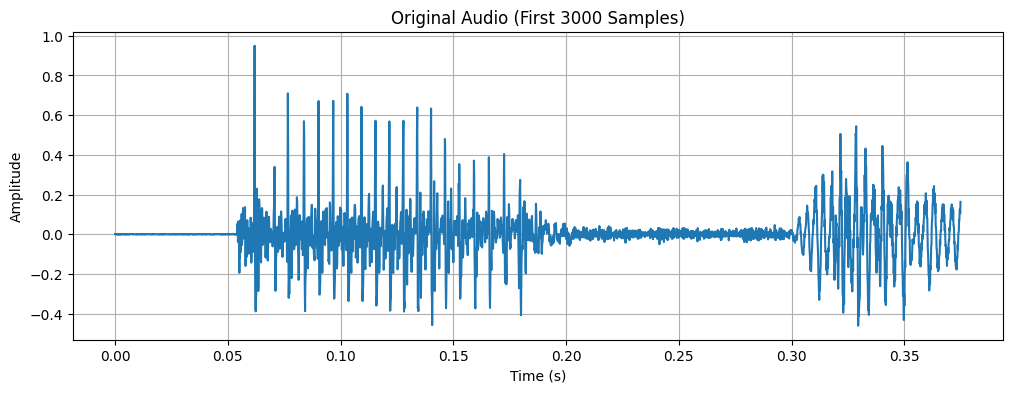

In [25]:
t = make_time_axis(len(audio), sample_rate)

plt.figure()
plt.plot(t[:3000], audio[:3000])
plt.title("Original Audio (First 3000 Samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## 5. Part A — Simple Modulation and Demodulation

Start with the simplest software version:
- build one carrier frequency
- modulate by multiplying the audio by the carrier
- demodulate by multiplying again with the same carrier
- then low-pass filter to recover the baseband audio

This is the cleanest first milestone for Wednesday.

In [26]:
carrier = make_single_carrier(len(audio), sample_rate, CARRIER_FREQ_HZ)

start_time = time.perf_counter()
modulated = audio * carrier
mixed_back = modulated * carrier
demodulated = 2.0 * lowpass_fft(mixed_back, sample_rate, cutoff_hz=2000)
demodulated = normalize_audio(demodulated)
elapsed_simple = time.perf_counter() - start_time

print(f"Simple modulation+demodulation time: {elapsed_simple:.6f} s")

Simple modulation+demodulation time: 0.002368 s


### Why the Low-Pass Filter is Needed

When you multiply by the carrier again, you create:
- the original low-frequency audio content
- extra high-frequency terms

The low-pass filter removes the high-frequency part and keeps the recovered audio.

### Save the Encrypted and Decrypted Files

In [27]:
save_wav_float(ENCRYPTED_WAV, sample_rate, modulated)
save_wav_float(DECRYPTED_WAV, sample_rate, demodulated)

print(f"Saved: {ENCRYPTED_WAV}")
print(f"Saved: {DECRYPTED_WAV}")

Saved: encrypted.wav
Saved: decrypted.wav


### Listen to the Encrypted Signal
It may sound unusual or noisy depending on the carrier and playback system.

In [28]:
display(Audio(modulated, rate=sample_rate))

### Listen to the Decrypted Signal

In [29]:
display(Audio(demodulated, rate=sample_rate))

## 6. Compare Original vs Decrypted

In [30]:
simple_mse = mse(audio, demodulated)
simple_mae = mae(audio, demodulated)
simple_snr = snr_db(audio, demodulated)
simple_ber = approx_ber(audio, demodulated)

print("Simple carrier results")
print(f"MSE:        {simple_mse:.8f}")
print(f"MAE:        {simple_mae:.8f}")
print(f"SNR (dB):   {simple_snr:.4f}")
print(f"Approx BER: {simple_ber:.6f}")

Simple carrier results
MSE:        0.00052636
MAE:        0.01402918
SNR (dB):   11.0101
Approx BER: 0.071511


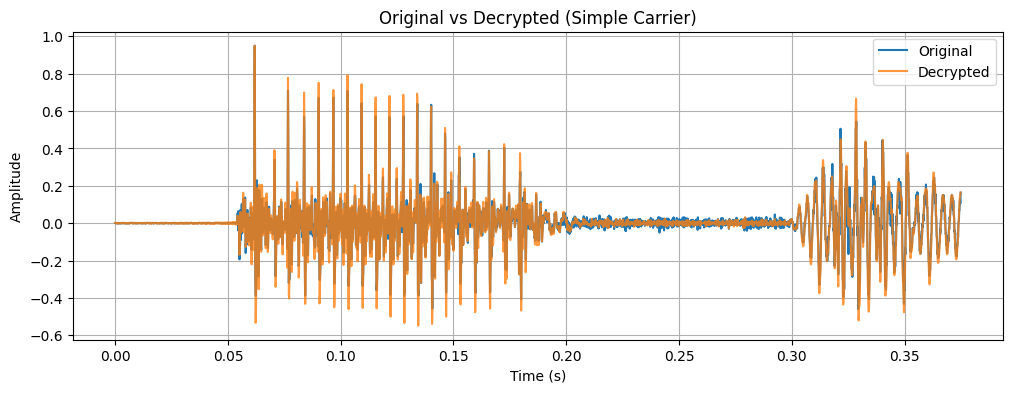

In [31]:
plt.figure()
plt.plot(t[:3000], audio[:3000], label="Original")
plt.plot(t[:3000], demodulated[:3000], label="Decrypted", alpha=0.8)
plt.title("Original vs Decrypted (Simple Carrier)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

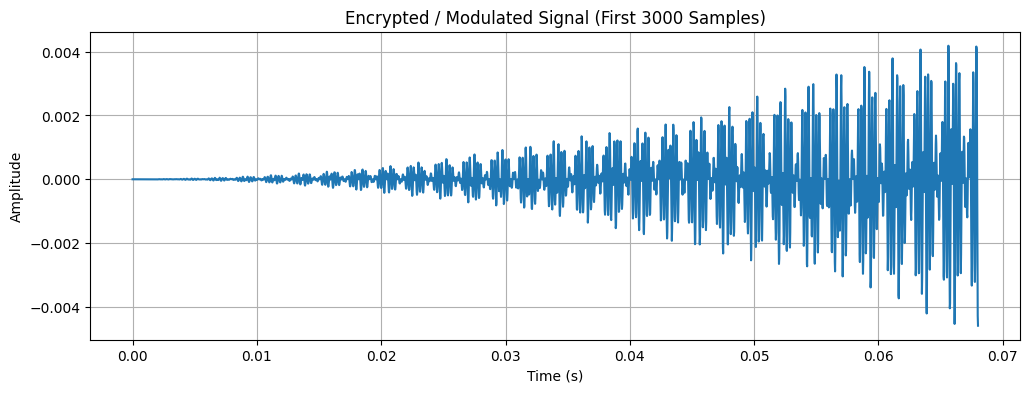

In [ ]:
plt.figure()
plt.plot(t[:3000], modulated[:3000])
plt.title("Encrypted / Modulated Signal (First 3000 Samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## 7. Part B — Basic FHSS-Style Hopping Carrier

Now extend the proof-of-concept so the carrier frequency changes over time.

This is not yet a full wireless system, but it matches the project idea much more closely:
- transmitter uses a hopping carrier
- receiver uses the same hopping pattern
- receiver multiplies again and low-pass filters

In [33]:
fhss_carrier = make_hopping_carrier(
    num_samples=len(audio),
    sample_rate=sample_rate,
    hop_freqs=HOP_FREQUENCIES,
    hop_samples=HOP_SAMPLES
)

start_time = time.perf_counter()
fhss_modulated = audio * fhss_carrier
fhss_mixed_back = fhss_modulated * fhss_carrier
fhss_demodulated = 2.0 * lowpass_fft(fhss_mixed_back, sample_rate, cutoff_hz=2000)
fhss_demodulated = normalize_audio(fhss_demodulated)
elapsed_fhss = time.perf_counter() - start_time

print(f"FHSS-style modulation+demodulation time: {elapsed_fhss:.6f} s")

FHSS-style modulation+demodulation time: 0.001250 s


### Listen to FHSS Decrypted Audio

In [34]:
display(Audio(fhss_demodulated, rate=sample_rate))

## 8. Evaluate FHSS-Style Results

In [35]:
fhss_mse = mse(audio, fhss_demodulated)
fhss_mae = mae(audio, fhss_demodulated)
fhss_snr = snr_db(audio, fhss_demodulated)
fhss_ber = approx_ber(audio, fhss_demodulated)

print("FHSS-style results")
print(f"MSE:        {fhss_mse:.8f}")
print(f"MAE:        {fhss_mae:.8f}")
print(f"SNR (dB):   {fhss_snr:.4f}")
print(f"Approx BER: {fhss_ber:.6f}")

FHSS-style results
MSE:        0.00161291
MAE:        0.02312239
SNR (dB):   6.1468
Approx BER: 0.115268


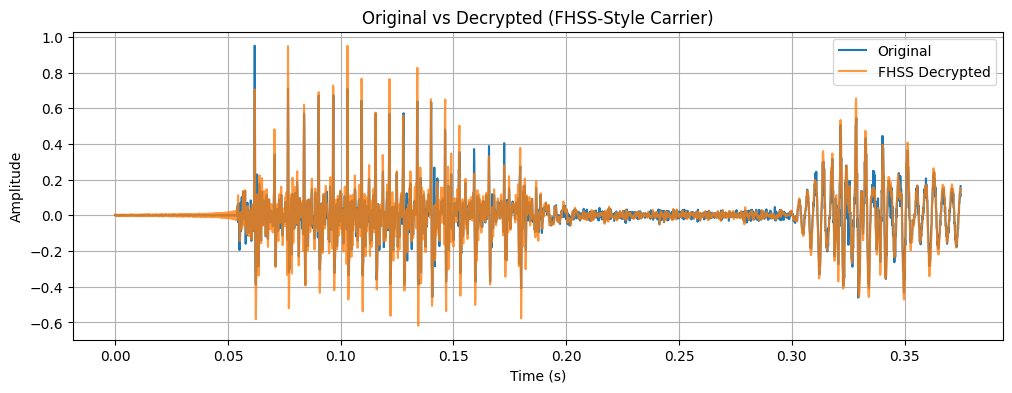

In [36]:
plt.figure()
plt.plot(t[:3000], audio[:3000], label="Original")
plt.plot(t[:3000], fhss_demodulated[:3000], label="FHSS Decrypted", alpha=0.8)
plt.title("Original vs Decrypted (FHSS-Style Carrier)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## 9. Show the Hopping Carrier Segments
This helps demonstrate that the frequency really changes over time.

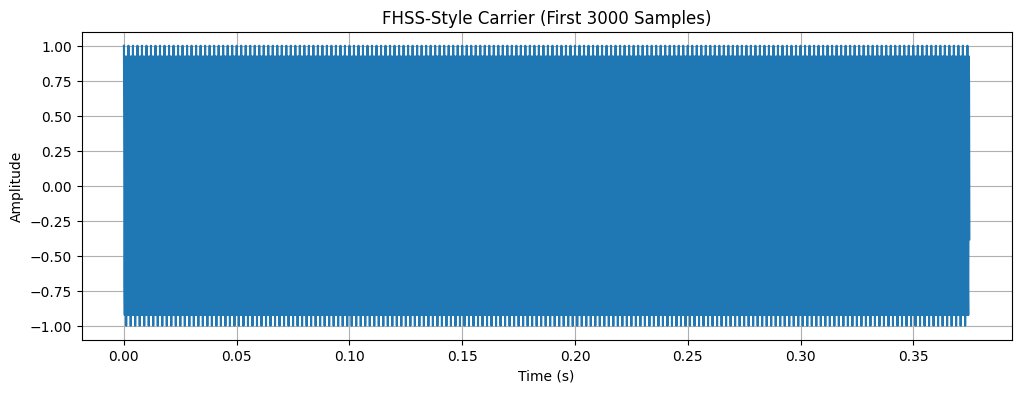

In [37]:
plt.figure()
plt.plot(t[:3000], fhss_carrier[:3000])
plt.title("FHSS-Style Carrier (First 3000 Samples)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## 10. Timing / Throughput Measurements

These software timing numbers are useful now and will be useful later when you compare PS vs PL.

In [38]:
simple_throughput = len(audio) / elapsed_simple
fhss_throughput = len(audio) / elapsed_fhss

print("Timing Summary")
print(f"Simple pipeline time: {elapsed_simple:.6f} s")
print(f"FHSS pipeline time:   {elapsed_fhss:.6f} s")
print(f"Simple throughput:    {simple_throughput:.2f} samples/s")
print(f"FHSS throughput:      {fhss_throughput:.2f} samples/s")

Timing Summary
Simple pipeline time: 0.002368 s
FHSS pipeline time:   0.001250 s
Simple throughput:    9921746.88 samples/s
FHSS throughput:      18790641.87 samples/s


## 11. Summary Table

In [39]:
results = {
    "Simple Carrier": {
        "MSE": simple_mse,
        "MAE": simple_mae,
        "SNR_dB": simple_snr,
        "Approx_BER": simple_ber,
        "Time_s": elapsed_simple,
        "Throughput_samples_per_s": simple_throughput,
    },
    "FHSS Style": {
        "MSE": fhss_mse,
        "MAE": fhss_mae,
        "SNR_dB": fhss_snr,
        "Approx_BER": fhss_ber,
        "Time_s": elapsed_fhss,
        "Throughput_samples_per_s": fhss_throughput,
    }
}

for name, vals in results.items():
    print(f"--- {name} ---")
    for k, v in vals.items():
        if isinstance(v, float):
            print(f"{k}: {v:.6f}")
        else:
            print(f"{k}: {v}")
    print()

--- Simple Carrier ---
MSE: 0.000526
MAE: 0.014029
SNR_dB: 11.010108
Approx_BER: 0.071511
Time_s: 0.002368
Throughput_samples_per_s: 9921746.882753

--- FHSS Style ---
MSE: 0.001613
MAE: 0.023122
SNR_dB: 6.146841
Approx_BER: 0.115268
Time_s: 0.001250
Throughput_samples_per_s: 18790641.871652



## 12. What This Demonstrates for the Project

This notebook already gives us a valid **software milestone**:
- input audio is loaded
- the signal is modulated
- the same carrier is used to demodulate it
- the output can be heard and compared
- timing and quality metrics are measured

## Good talking points for class/demo
- "We started with a software-only prototype on the PS."
- "We implemented both a simple carrier and a basic FHSS-style hopping carrier."
- "We can recover the audio by using the same carrier pattern on the receiver side."
- "We measured error and timing so we have a baseline for FPGA acceleration later."

## Natural next steps
1. Replace the fixed hop list with an LFSR-generated hop sequence
2. Packetize the audio into chunks
3. Track packet loss and per-packet errors
4. Move carrier generation and multiply operations into FPGA hardware
5. Compare PS vs PL timing

## 13. Optional Extension: LFSR Hop Sequence Generator

This cell is optional, but it gives you a starting point for replacing the fixed hop sequence with a pseudo-random pattern.

In [40]:
def lfsr_sequence(seed=0b1011, taps=(3, 2), length=16):
    '''
    Simple integer LFSR example.
    taps are bit positions counted from 0 at the least-significant bit.
    '''
    state = seed
    seq = []

    if state == 0:
        raise ValueError("Seed must be nonzero.")

    width = max(taps) + 1

    for _ in range(length):
        seq.append(state)
        new_bit = 0
        for tap in taps:
            new_bit ^= (state >> tap) & 1
        state = (state >> 1) | (new_bit << (width - 1))

    return seq


seq = lfsr_sequence(length=12)
print("Example LFSR states:", seq)

# Map states to carrier frequencies
freq_choices = [1500, 2500, 3500, 4500]
mapped_freqs = [freq_choices[s % len(freq_choices)] for s in seq]
print("Mapped hop frequencies:", mapped_freqs)

Example LFSR states: [11, 13, 6, 11, 13, 6, 11, 13, 6, 11, 13, 6]
Mapped hop frequencies: [4500, 2500, 3500, 4500, 2500, 3500, 4500, 2500, 3500, 4500, 2500, 3500]


## 14. Final Note

Bring this notebook to class with either:
- a generated test signal, or
- a real short `.wav` file,

we have a complete and defensible software implementation for this week's milestone :)

In [41]:
fhss_carrier = make_hopping_carrier(
    num_samples=len(audio),
    sample_rate=sample_rate,
    hop_freqs=freq_choices,
    hop_samples=HOP_SAMPLES
)

start_time = time.perf_counter()
fhss_modulated = audio * fhss_carrier
fhss_mixed_back = fhss_modulated * fhss_carrier
fhss_demodulated = 2.0 * lowpass_fft(fhss_mixed_back, sample_rate, cutoff_hz=2000)
fhss_demodulated = normalize_audio(fhss_demodulated)
elapsed_fhss = time.perf_counter() - start_time

print(f"FHSS-style modulation+demodulation time: {elapsed_fhss:.6f} s")

FHSS-style modulation+demodulation time: 0.001022 s


In [42]:
print('hello')

hello


=== STEP 1: Load audio ===
  Loaded input.wav  sr=8000  samples=23493

=== STEP 2: Write raw UDP packets ===
  Wrote 184 packets (93972 bytes) -> packets.bin

=== STEP 3: Read back UDP packets ===
  Read 184 packets -> 93972 bytes
  Round-trip match: True

=== STEP 4: XOR encrypt -> write encrypted packets ===
  Wrote 184 packets (93972 bytes) -> packets_encrypted.bin

=== STEP 5: Read encrypted packets -> XOR decrypt ===
  Read 184 packets -> 93972 bytes
  Decrypt match: True

=== STEP 6: FHSS modulate encrypted audio ===
  FHSS round-trip time: 0.0065s
  Max abs error: 0.497680


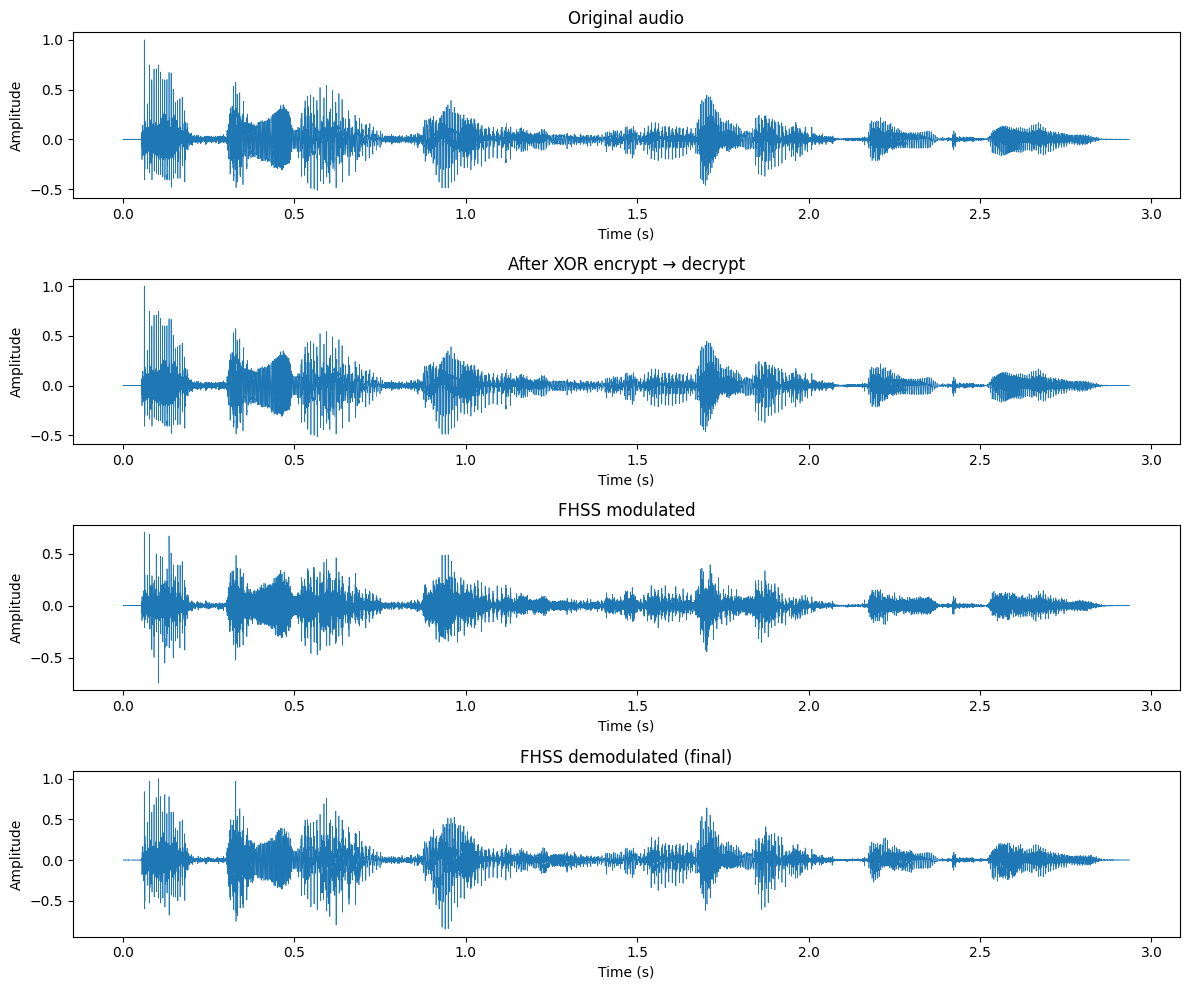

In [ ]:
# ============================================================
# WAV -> UDP Packets -> XOR Encryption -> FHSS
# ============================================================

import os
import struct
import time
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

plt.rcParams["figure.figsize"] = (12, 4)
np.set_printoptions(suppress=True, precision=4)


# ============================================================
# SECTION 1 — CONFIG
# ============================================================

INPUT_WAV      = "input.wav"       # path to your .wav file
PACKET_FILE    = "packets.bin"     # simulated UDP packet dump
PAYLOAD_SIZE   = 512               # bytes per UDP payload
XOR_KEY        = b"secretkey1234"  # XOR encryption key
SAMPLE_RATE    = 16000             # used if generating test signal

# FHSS config
HOP_FREQS      = [1000, 1500, 2000, 2500, 3000]  # Hz
HOP_SAMPLES    = 512


# ============================================================
# SECTION 2 — HELPERS
# ============================================================

def load_audio(path):
    """Load a wav file as float32 mono, normalised to [-1, 1]."""
    audio, sr = sf.read(path, dtype="float32", always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)          # stereo -> mono
    audio /= np.max(np.abs(audio) + 1e-9)  # normalise
    return audio, sr

def generate_test_signal(sr=SAMPLE_RATE, duration=2.0):
    """440 Hz sine wave — used when no wav file is present."""
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    audio = 0.5 * np.sin(2 * np.pi * 440 * t).astype(np.float32)
    return audio, sr

def audio_to_bytes(audio):
    """Convert float32 numpy array to raw bytes (PCM float32 LE)."""
    return audio.astype(np.float32).tobytes()

def bytes_to_audio(raw):
    """Convert raw bytes back to float32 numpy array."""
    return np.frombuffer(raw, dtype=np.float32).copy()


# ============================================================
# SECTION 3 — SIMULATED UDP PACKETS
# ============================================================
# Packet format (fixed header, 12 bytes):
#   [4B seq_num][4B total_packets][4B payload_len][NB payload]

HEADER_FMT  = ">III"   # big-endian: seq, total, payload_len
HEADER_SIZE = struct.calcsize(HEADER_FMT)  # 12 bytes

def pack_packet(seq, total, payload: bytes) -> bytes:
    header = struct.pack(HEADER_FMT, seq, total, len(payload))
    return header + payload

def unpack_packet(data: bytes):
    seq, total, payload_len = struct.unpack(HEADER_FMT, data[:HEADER_SIZE])
    payload = data[HEADER_SIZE: HEADER_SIZE + payload_len]
    return seq, total, payload

def write_packets(raw_bytes: bytes, filepath: str, payload_size=PAYLOAD_SIZE):
    """Chunk raw_bytes into fixed-size payloads and write to a binary file."""
    chunks = [raw_bytes[i:i+payload_size]
              for i in range(0, len(raw_bytes), payload_size)]
    total  = len(chunks)
    with open(filepath, "wb") as f:
        for seq, chunk in enumerate(chunks):
            f.write(pack_packet(seq, total, chunk))
    print(f"  Wrote {total} packets ({len(raw_bytes)} bytes) -> {filepath}")

def read_packets(filepath: str) -> bytes:
    """Read packet file and reassemble payloads in sequence order."""
    packets = {}
    with open(filepath, "rb") as f:
        while True:
            hdr = f.read(HEADER_SIZE)
            if len(hdr) < HEADER_SIZE:
                break
            seq, total, payload_len = struct.unpack(HEADER_FMT, hdr)
            payload = f.read(payload_len)
            packets[seq] = payload
    # reassemble in order
    raw = b"".join(packets[i] for i in range(len(packets)))
    print(f"  Read {len(packets)} packets -> {len(raw)} bytes")
    return raw


# ============================================================
# SECTION 4 — XOR ENCRYPTION
# ============================================================

def xor_crypt(data: bytes, key: bytes) -> bytes:
    """XOR each byte with a repeating key — same function encrypts & decrypts."""
    key_len = len(key)
    return bytes(b ^ key[i % key_len] for i, b in enumerate(data))


# ============================================================
# SECTION 5 — FHSS
# ============================================================

def make_hopping_carrier(num_samples, sample_rate, hop_freqs, hop_samples):
    """Build a carrier that hops between frequencies every hop_samples."""
    t       = np.arange(num_samples) / sample_rate
    carrier = np.zeros(num_samples, dtype=np.float32)
    phase   = 0.0
    i       = 0
    freq_idx = 0
    while i < num_samples:
        end   = min(i + hop_samples, num_samples)
        freq  = hop_freqs[freq_idx % len(hop_freqs)]
        block = np.arange(end - i)
        carrier[i:end] = np.cos(2 * np.pi * freq * block / sample_rate + phase)
        phase += 2 * np.pi * freq * (end - i) / sample_rate
        i      = end
        freq_idx += 1
    return carrier

def lowpass_filter(audio, sample_rate, cutoff=4000, order=5):
    nyq = sample_rate / 2
    b, g = butter(order, cutoff / nyq, btype="low")
    return filtfilt(b, g, audio).astype(np.float32)

def fhss_modulate(audio, sample_rate, hop_freqs=HOP_FREQS, hop_samples=HOP_SAMPLES):
    carrier = make_hopping_carrier(len(audio), sample_rate, hop_freqs, hop_samples)
    return (audio * carrier).astype(np.float32), carrier

def fhss_demodulate(modulated, carrier, sample_rate, cutoff=2000):
    mixed = modulated * carrier
    recovered = 2.0 * lowpass_filter(mixed, sample_rate, cutoff)
    recovered /= np.max(np.abs(recovered) + 1e-9)
    return recovered.astype(np.float32)


# ============================================================
# SECTION 6 — PIPELINE
# ============================================================

print("=== STEP 1: Load audio ===")
if os.path.exists(INPUT_WAV):
    audio, sr = load_audio(INPUT_WAV)
    print(f"  Loaded {INPUT_WAV}  sr={sr}  samples={len(audio)}")
else:
    audio, sr = generate_test_signal()
    print(f"  No wav found — generated 440 Hz test tone  sr={sr}  samples={len(audio)}")

# --- Step 2: Write raw packets ---
print("\n=== STEP 2: Write raw UDP packets ===")
raw_bytes = audio_to_bytes(audio)
write_packets(raw_bytes, PACKET_FILE)

# --- Step 3: Read back and verify ---
print("\n=== STEP 3: Read back UDP packets ===")
recovered_bytes = read_packets(PACKET_FILE)
recovered_audio = bytes_to_audio(recovered_bytes[:len(raw_bytes)])
print(f"  Round-trip match: {np.allclose(audio, recovered_audio)}")

# --- Step 4: XOR encrypt -> write packets ---
print("\n=== STEP 4: XOR encrypt -> write encrypted packets ===")
encrypted_bytes = xor_crypt(raw_bytes, XOR_KEY)
write_packets(encrypted_bytes, "packets_encrypted.bin")

# --- Step 5: Read encrypted packets -> XOR decrypt ---
print("\n=== STEP 5: Read encrypted packets -> XOR decrypt ===")
enc_read   = read_packets("packets_encrypted.bin")
dec_bytes  = xor_crypt(enc_read, XOR_KEY)
dec_audio  = bytes_to_audio(dec_bytes[:len(raw_bytes)])
print(f"  Decrypt match: {np.allclose(audio, dec_audio)}")

# --- Step 6: FHSS on top of XOR-encrypted audio ---
print("\n=== STEP 6: FHSS modulate encrypted audio ===")
dec_audio_f32 = dec_audio.astype(np.float32)
t0 = time.perf_counter()
fhss_mod, carrier = fhss_modulate(dec_audio_f32, sr)
fhss_demod        = fhss_demodulate(fhss_mod, carrier, sr)
print(f"  FHSS round-trip time: {time.perf_counter()-t0:.4f}s")
print(f"  Max abs error: {np.max(np.abs(dec_audio_f32 - fhss_demod)):.6f}")

# ============================================================
# SECTION 7 — VISUALISE
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(12, 10))
t_axis = np.arange(len(audio)) / sr

axes[0].plot(t_axis, audio,        lw=0.5); axes[0].set_title("Original audio")
axes[1].plot(t_axis, dec_audio,    lw=0.5); axes[1].set_title("After XOR encrypt → decrypt")
axes[2].plot(t_axis, fhss_mod,     lw=0.5); axes[2].set_title("FHSS modulated")
axes[3].plot(t_axis, fhss_demod,   lw=0.5); axes[3].set_title("FHSS demodulated (final)")

for ax in axes:
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [44]:
sf.write("output_original.wav",   audio,        sr)
sf.write("output_xor_decrypted.wav", dec_audio, sr)
sf.write("output_fhss_modulated.wav", fhss_mod,  sr)
sf.write("output_fhss_demodulated.wav", fhss_demod, sr)

print("Saved 4 wav files!")

Saved 4 wav files!
